> # Апенко Константин Сергеевич
## 7группа, 3 курс
19.02.2026

> ## Вариант №27


> # ЛАБОРАТОРНАЯ РАБОТА № 1
> ## МОДЕЛИРОВАНИЕ ДИСКРЕТНОЙ СЛУЧАЙНОЙ ВЕЛИЧИНЫ 


1.	Разработать алгоритм моделирования заданной дискретной случайной величины и программно его реализовать.
2.	Провести тестовую проверку созданного генератора:
•	получить оценку математического ожидания генерируемой случайной величины и сравнить ее с математическим ожиданием заданной;
•	получить оценку дисперсии генерируемой случайной величины и сравнить ее с дисперсией заданной величины;
•	проверить гипотезу о соответствии генерируемой случайной величины заданному распределению по критерию 2;
•	построить графики заданной функции распределения случайной величины и функции распределения, полученной по сгенерированной выборке.


Рассматривается гипергеометрическое распределение:

$$P(X=x)=\frac{\binom{R}{x}\binom{N-R}{m-x}}{\binom{N}{m}}, \quad x=0,1,...,\min(R,m)$$

# Алгоритм моделирования гипергеометрической случайной величины

1. **Задаем параметры распределения**:
   - N — размер генеральной совокупности
   - R — количество "успешных" элементов
   - m — размер выборки
   - sample_size — количество генерируемых значений

2. **Вычисляем теоретические вероятности** для всех возможных значений X:
  

3. **Генерируем выборку** из гипергеометрического распределения (`np.random.hypergeometric`).

4. **Считаем эмпирические характеристики**:
   - Математическое ожидание: среднее выборки
   - Дисперсию: выборочную дисперсию

5. **Сравниваем с теоретическими значениями**, полученными по формуле распределения.

6. **Проверяем гипотезу χ²**:

7. **Строим графики функций распределения**:
   - Теоретическая функция распределения 
   - Эмпирическая функция распределения

8. **Составляем таблицу распределения** 

In [252]:
import numpy as np
import math
import matplotlib.pyplot as plt



## Задание параметров

In [253]:
N = 50 # размер генеральной совокупности
R = 20  # число "успешных" элементов
m = 10  # размер выборки
sample_size = 10000 # размер выборки для моделирования


## Теоретическое распределение

In [254]:
def comb(n, k): # биномиальнкоэффициент
    return math.comb(n, k)

def hypergeom_p(x):
    return comb(R, x) * comb(N - R, m - x) / comb(N, m) # Теоретическая вероятность

x_values = list(range(0, min(R, m) + 1)) # Список всех возможных значений X
p_values = [hypergeom_p(x) for x in x_values] # Теоретические вероятности


## Моделирование выборки

In [255]:
sample = np.random.hypergeometric(R, N - R, m, sample_size) # Используем встроенную генерацию гипергеометрического распределения

emp_mean = np.mean(sample)
emp_var = np.var(sample, ddof=1)

theor_mean = m * R / N
theor_var = m * R / N * (1 - R / N) * (N - m) / (N - 1)

emp_mean, theor_mean, emp_var, theor_var

print("Математическое ожидание:")
print(f" Теоретическое: {theor_mean:.4f}")
print(f" Эмпирическое: {emp_mean:.4f}\n")

print("Дисперсия:")
print(f" Теоретическая: {theor_var:.4f}")
print(f" Эмпирическая: {emp_var:.4f}\n")


Математическое ожидание:
 Теоретическое: 4.0000
 Эмпирическое: 4.0250

Дисперсия:
 Теоретическая: 1.9592
 Эмпирическая: 1.9452



Эмпирические оценки близки к теоретическим => генератор работает корректно.

## Проверка гипотезы χ²

In [256]:
obs_counts = [np.sum(sample == x) for x in x_values]

# Ожидаемое количество по формуле P(X=x)
exp_counts = [sample_size * p for p in p_values]

# Статистика χ² (наглядно)
chi2_stat = sum((o - e)**2 / e for o, e in zip(obs_counts, exp_counts))
print("Проверка гипотезы χ²:")
print(f" Статистика χ²: {chi2_stat:.4f}")
print(" Критическую область можно оценить по таблице χ² с df = len(x_values)-1")
if chi2_stat < 16.919:  # критическое значение χ² для df=9 и α=0.05
    print(" Вывод: гипотеза о соответствии генератора заданному распределению принимается!!! УРА")
else:
    print(" Вывод: гипотеза отвергается")



Проверка гипотезы χ²:
 Статистика χ²: 8.6980
 Критическую область можно оценить по таблице χ² с df = len(x_values)-1
 Вывод: гипотеза о соответствии генератора заданному распределению принимается!!! УРА


Теоретическое математическое ожидание: 

E[X]=m⋅R/N

Эмпирическое (генерируемое) 

E^[X]=среднее по выборке

## Теоретическая функция распределения

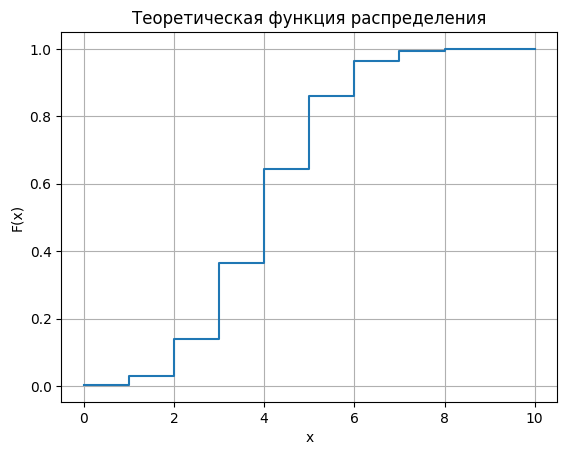

In [257]:
cdf_theor = np.cumsum(p_values)
plt.figure()
plt.step(x_values, cdf_theor, where='post')
plt.title('Теоретическая функция распределения')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid(True)
plt.show()


## Эмпирическая функция распределения

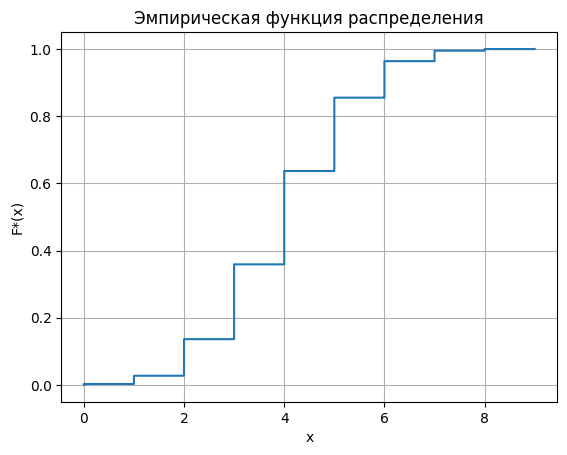

In [258]:
sorted_sample = np.sort(sample)
ecdf = np.arange(1, sample_size + 1) / sample_size

plt.figure()
plt.step(sorted_sample, ecdf, where='post')
plt.title('Эмпирическая функция распределения')
plt.xlabel('x')
plt.ylabel('F*(x)')
plt.grid(True)
plt.show()


In [259]:
import pandas as pd
df = pd.DataFrame({
    "x": x_values,
    "P(X=x) Теоретическое": p_values,
    "Количество в выборке": obs_counts,
    "P*(X=x) Эмпирическое": np.array(obs_counts)/sample_size
})
df

,x,P(X=x) Теоретическое,Количество в выборке,P*(X=x) Эмпирическое
0,0,0.002925,28,0.0028
1,1,0.027856,246,0.0246
2,2,0.108258,1089,0.1089
3,3,0.225930,2226,0.2226
4,4,0.280059,2778,0.2778
5,5,0.215085,2183,0.2183
6,6,0.103406,1086,0.1086
7,7,0.030639,312,0.0312
8,8,0.005334,47,0.0047
9,9,0.000491,5,0.0005


---------------------------------------------------------------------------------------------------------------

> # ЛАБОРАТОРНАЯ РАБОТА № 2
# Вариант 8
> ## МОДЕЛИРОВАНИЕ НЕПРЕРЫВНОЙ СЛУЧАЙНОЙ ВЕЛИЧИНЫ 

Метод обратной функции

Плотность распределения случайной величины:

𝑓
(
𝑥
)
=𝑥\2 ,x∈[0;2]

# 1. Разработка алгоритма моделирования случайной величины

In [260]:
import numpy as np
import matplotlib.pyplot as plt

sample_size = 10000
alpha = 0.05

Алгоритм моделирования случайной величины

Сначала нашли функцию распределения: КАК ИНТЕГРАЛ ПЛОТНОСТИ

𝐹=x^2/4

Выразили x=2кореньU

In [ ]:
u = np.random.rand(sample_size) # равномерное распределение на [0,1].
sample = 2 * np.sqrt(u) #Эта формула получена из обратной функции распределения.

# Теоретические характеристики

In [262]:
theor_mean = 4/3
theor_var = 2/9

## 2. Тестовая проверка генератора
## Эмпирические характеристики

In [263]:
emp_mean = np.mean(sample)
emp_var = np.var(sample, ddof=1)

print("Математическое ожидание")
print("Теоретическое:", theor_mean)
print("Эмпирическое:", emp_mean)

print("\nДисперсия")
print("Теоретическая:", theor_var)
print("Эмпирическая:", emp_var)

Математическое ожидание
Теоретическое: 1.3333333333333333
Эмпирическое: 1.3350612249662706

Дисперсия
Теоретическая: 0.2222222222222222
Эмпирическая: 0.22079846532197858


# Доверительный интервал для математического ожидания

(используем квантиль 1.96 для 95%)

In [264]:
std = np.std(sample, ddof=1)

z = 1.96

left = emp_mean - z * std / np.sqrt(sample_size)
right = emp_mean + z * std / np.sqrt(sample_size)

print("\nДоверительный интервал для математического ожидания:")
print(left, "< μ <", right)


Доверительный интервал для математического ожидания:
1.325851342315656 < μ < 1.3442711076168852


Проверка гипотезы χ²

Разбиваем интервал на группы.

In [265]:
k = 10

bins = np.linspace(0,2,k+1)

obs_counts = []

for i in range(k):
    count = np.sum((sample >= bins[i]) & (sample < bins[i+1]))
    obs_counts.append(count)

obs_counts = np.array(obs_counts)

Теоретические вероятности


In [266]:
def F(x):
    return x**2 / 4

p_values = []

for i in range(k):
    p = F(bins[i+1]) - F(bins[i])
    p_values.append(p)

p_values = np.array(p_values)

exp_counts = sample_size * p_values

Статистика χ²

In [267]:
chi2_stat = np.sum((obs_counts - exp_counts)**2 / exp_counts)

df = k - 1

chi2_crit = 16.919   # значение из таблицы χ² для df=9 и α=0.05

print("\nКритерий χ²")
print("Статистика:", chi2_stat)
print("Критическое значение:", chi2_crit)

if chi2_stat < chi2_crit:
    print("Гипотеза принимается")
else:
    print("Гипотеза отвергается")


Критерий χ²
Статистика: 3.2958571679437996
Критическое значение: 16.919
Гипотеза принимается


# Критерий ω² (Крамера–фон Мизеса)

Идея

Критерий измеряет среднее квадратичное расстояние между:

эмпирической функцией распределения 


теоретической функцией 



In [268]:
sorted_sample = np.sort(sample)
#считаем статистику
n = sample_size

omega2 = 1/(12*n)

for i in range(n):
    omega2 += (F(sorted_sample[i]) - (2*(i+1)-1)/(2*n))**2

print("\nКритерий ω²")
print("Статистика ω²:", omega2)


Критерий ω²
Статистика ω²: 0.026065019197202687


Сравниваем с табличным значением.

Для уровня значимости:

α=0.05

критическое значение:
ω
crit
2​≈0.461

In [269]:
omega2_crit = 0.461

print("Критерий ω²")
print("Статистика:", omega2)

if omega2 < omega2_crit:
    print("Гипотеза принимается")
else:
    print("Гипотеза отвергается")

Критерий ω²
Статистика: 0.026065019197202687
Гипотеза принимается


Теоретическая плотность

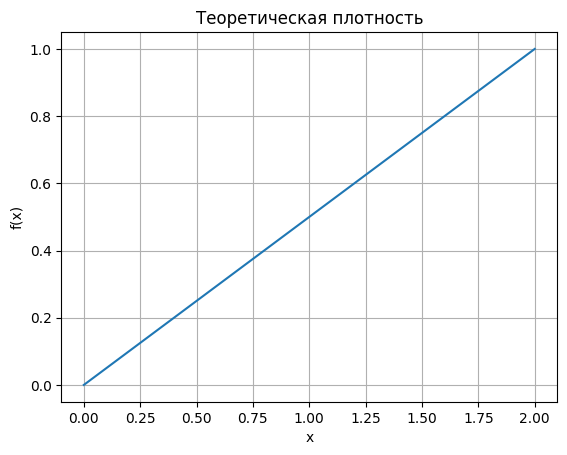

In [270]:
x = np.linspace(0,2,1000)
f = x/2

plt.figure()
plt.plot(x,f)
plt.title("Теоретическая плотность")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

Гистограмма выборки

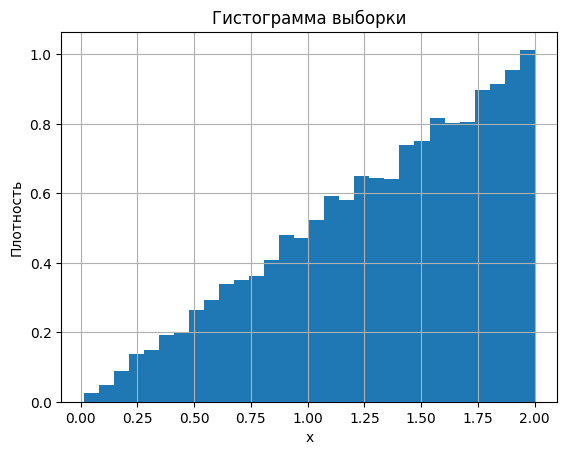

In [271]:
plt.figure()
plt.hist(sample, bins=30, density=True)
plt.title("Гистограмма выборки")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.grid()
plt.show()

Сравнение плотностей

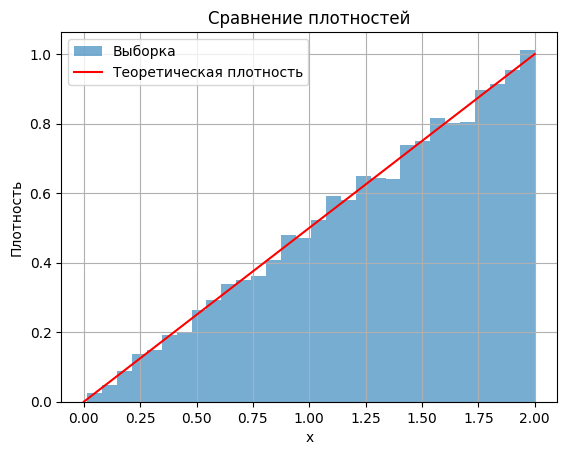

In [272]:
plt.figure()

plt.hist(sample, bins=30, density=True, alpha=0.6, label="Выборка")
plt.plot(x, f, 'r', label="Теоретическая плотность")

plt.legend()
plt.title("Сравнение плотностей")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.grid()

plt.show()